Nama: Alfin Oktavian

NIM: 240401010282

Kelas: IF-403

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [ ]:
# LOAD & INSPECT DATASET ──────────────────────────────────────────
df = sns.load_dataset('diamonds')

# INFORMASI DATA
print("Shape Dataset:")
print(df.shape)

print("\nTipe Data:")
print(df.dtypes)

print("\nStatistik Deskriptif:")
print(df.describe().round(2))

Shape Dataset:
(53940, 10)

Tipe Data:
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

Statistik Deskriptif:
          carat     depth     table     price         x         y         z
count  53940.00  53940.00  53940.00  53940.00  53940.00  53940.00  53940.00
mean       0.80     61.75     57.46   3932.80      5.73      5.73      3.54
std        0.47      1.43      2.23   3989.44      1.12      1.14      0.71
min        0.20     43.00     43.00    326.00      0.00      0.00      0.00
25%        0.40     61.00     56.00    950.00      4.71      4.72      2.91
50%        0.70     61.80     57.00   2401.00      5.70      5.71      3.53
75%        1.04     62.50     59.00   5324.25      6.54      6.54      4.04
max        5.01     79.00     95.00  18823.00     10.74     58.90     31.80


/tmp/ipykernel_1966/796122833.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_cut = df.groupby('cut')['price'].mean()


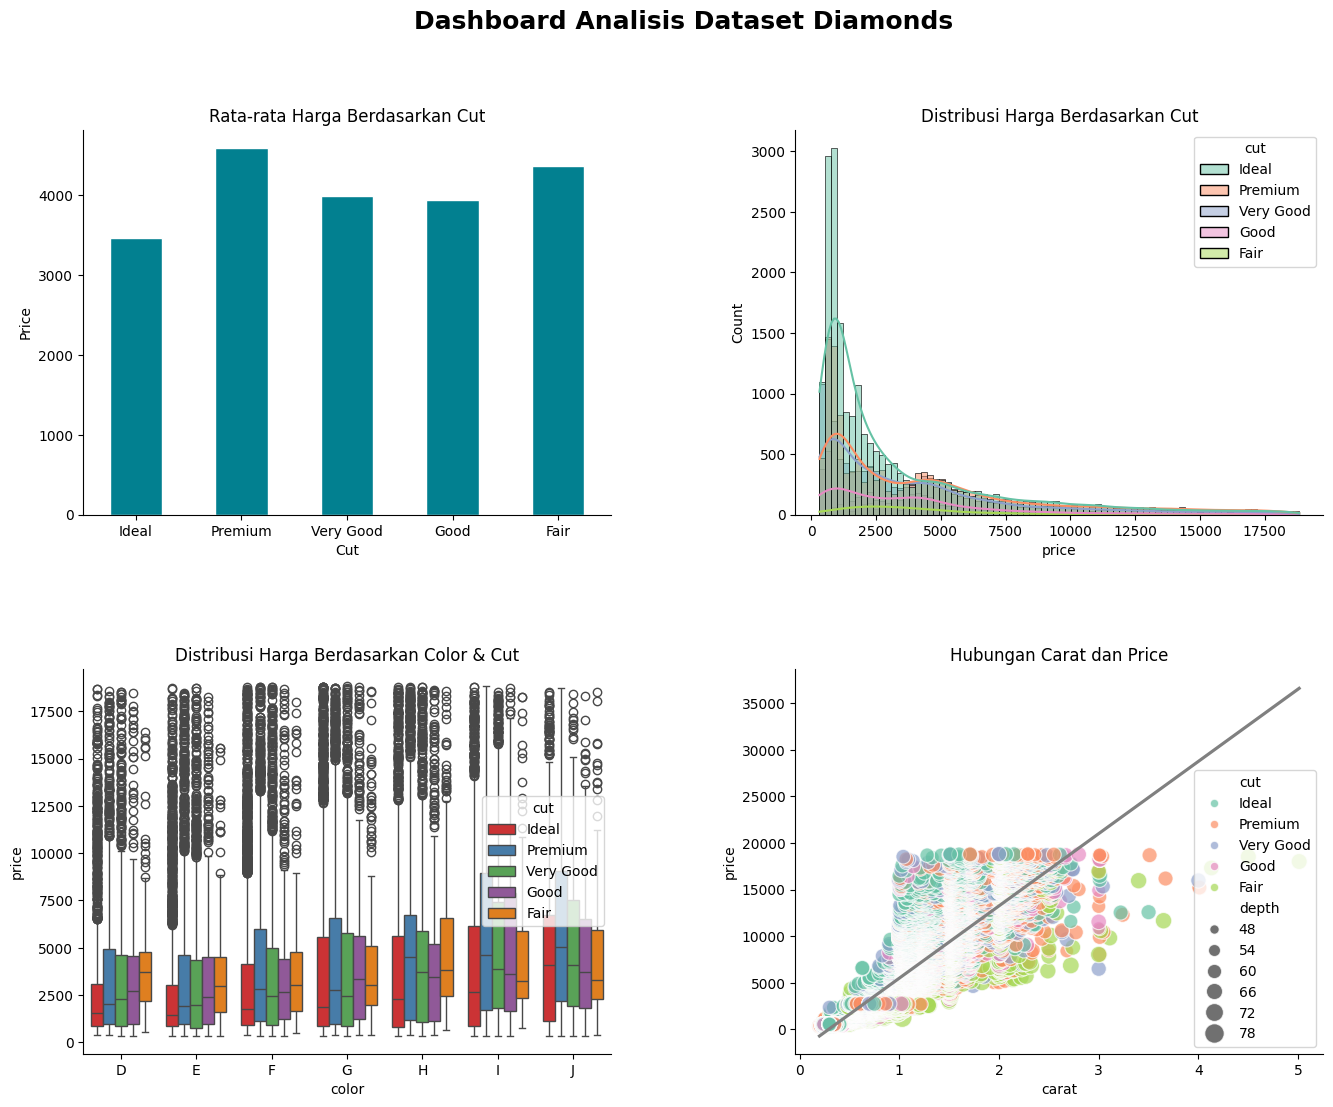

Dashboard tersimpan sebagai 'dashboard_diamonds.png'


In [ ]:
# SETUP FIGURE LAYOUT ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))

fig.suptitle(
    'Dashboard Analisis Dataset Diamonds',
    fontsize=18,
    fontweight='bold',
    y=0.98
)

# Layout Grid 2x2
gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    hspace=0.4,
    wspace=0.35
)

# Membuat subplot
ax1 = fig.add_subplot(gs[0, 0])  # kiri atas
ax2 = fig.add_subplot(gs[0, 1])  # kanan atas
ax3 = fig.add_subplot(gs[1, 0])  # kiri bawah
ax4 = fig.add_subplot(gs[1, 1])  # kanan bawah

# GRAFIK 1: Bar Chart ─────────────────────────────────────────────
# Rata-rata harga berdasarkan cut

avg_price_cut = df.groupby('cut')['price'].mean()

avg_price_cut.plot(
    kind='bar',
    ax=ax1,
    color='#028090',
    edgecolor='white'
)

ax1.set_title('Rata-rata Harga Berdasarkan Cut')
ax1.set_xlabel('Cut')
ax1.set_ylabel('Price')
ax1.tick_params(axis='x', rotation=0)

# Menghilangkan garis atas & kanan
ax1.spines[['top', 'right']].set_visible(False)

# GRAFIK 2: Histogram + KDE ───────────────────────────────────────
# Distribusi harga berdasarkan cut

sns.histplot(
    data=df,
    x='price',
    hue='cut',
    kde=True,
    palette='Set2',
    ax=ax2
)

ax2.set_title('Distribusi Harga Berdasarkan Cut')
ax2.spines[['top', 'right']].set_visible(False)

# GRAFIK 3: Boxplot ───────────────────────────────────────────────
# Distribusi harga berdasarkan color & cut

sns.boxplot(
    data=df,
    x='color',
    y='price',
    hue='cut',
    palette='Set1',
    ax=ax3
)

ax3.set_title('Distribusi Harga Berdasarkan Color & Cut')
ax3.spines[['top', 'right']].set_visible(False)

# =========================================================
#  GRAFIK 4: Scatter Plot + REGRESSION LINE─────────────────────────
# Hubungan carat dan price

sns.scatterplot(
    data=df,
    x='carat',
    y='price',
    hue='cut',
    size='depth',
    sizes=(20, 200),
    palette='Set2',
    alpha=0.7,
    ax=ax4
)

# Garis regresi
sns.regplot(
    data=df,
    x='carat',
    y='price',
    scatter=False,
    color='gray',
    ax=ax4
)

ax4.set_title('Hubungan Carat dan Price')
ax4.spines[['top', 'right']].set_visible(False)

# EXPORT DASHBOARD───────────────────────────────────────────────────

plt.savefig(
    'dashboard_diamonds.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Dashboard tersimpan sebagai 'dashboard_diamonds.png'")

Bar Chart — Rata-rata Harga Berdasarkan Cut
What? Kategori Premium memiliki rata-rata harga berlian tertinggi, sedangkan Ideal memiliki rata-rata harga terendah. Terdapat perbedaan harga yang cukup jelas antar kategori cut.

So what? Hasil ini menunjukkan bahwa kualitas potongan (cut) berpengaruh terhadap harga berlian, tetapi bukan satu-satunya faktor yang menentukan nilai jualnya.

Now what? Perlu dilakukan analisis lebih lanjut dengan mempertimbangkan faktor lain seperti carat, clarity, dan color untuk mengetahui faktor yang paling memengaruhi harga berlian.

Histogram — Distribusi Harga Berdasarkan Cut
What? Sebagian besar harga berlian berada pada rentang harga rendah hingga menengah, dengan distribusi yang cenderung miring ke kanan.

Kategori Ideal memiliki jumlah data terbanyak, sedangkan berlian dengan harga sangat tinggi jumlahnya relatif sedikit.

So what? Hal ini menunjukkan bahwa pasar berlian didominasi oleh produk dengan harga yang lebih terjangkau.

Selain itu, adanya distribusi yang tidak simetris mengindikasikan keberadaan beberapa nilai harga yang jauh lebih tinggi dibanding mayoritas data.

Now what? Analisis selanjutnya dapat menggunakan median dan kuartil untuk menggambarkan harga secara lebih representatif.

Transformasi log pada variabel harga dapat dicoba untuk membantu proses analisis statistik yang lebih akurat.

Boxplot — Distribusi Harga Berdasarkan Color & Cut
What? Boxplot menunjukkan bahwa median harga cenderung meningkat pada kategori warna yang lebih rendah (mendekati J).

Terdapat banyak outlier dengan harga yang sangat tinggi pada hampir semua kategori warna.

So what? Hasil ini mengindikasikan bahwa warna bukan satu-satunya faktor yang menentukan harga berlian.

Berlian dengan warna yang kurang baik tetap dapat memiliki harga tinggi karena dipengaruhi oleh faktor lain, seperti ukuran carat atau tingkat kejernihan.

Now what? Analisis selanjutnya dapat dilakukan dengan mengelompokkan data berdasarkan ukuran carat dan menganalisis korelasi antar fitur untuk mengetahui faktor yang paling berpengaruh terhadap harga berlian.

Scatter Plot — Hubungan Carat dan Price
What? Scatter plot menunjukkan adanya hubungan positif yang kuat antara ukuran carat dan harga berlian.

Semakin besar carat, semakin tinggi harga berlian, dengan sebagian besar data berada pada rentang 0,5–2 carat.

So what? Hal ini menunjukkan bahwa ukuran carat merupakan salah satu faktor utama yang memengaruhi harga berlian.

Hubungan yang terlihat cukup kuat juga mengindikasikan bahwa carat dapat menjadi variabel penting dalam analisis dan prediksi harga.

Now what? Analisis selanjutnya dapat dilakukan dengan menghitung nilai korelasi serta membangun model regresi untuk memprediksi harga berlian menggunakan carat dan faktor lain seperti cut, color, dan clarity.

Kesimpulan singkat:

Pada pertemuan ke 5 ini, dashboard visualisasi data dataset Diamonds dibuat menggunakan Matplotlib dan Seaborn, meliputi bar chart, histogram, boxplot, dan scatter plot.

Temuan utamanya adalah hubungan positif kuat antara karat dan harga, serta pengaruh kualitas potongan (cut) terhadap rata-rata harga berlian.

Analisis ini masih bersifat eksplorasi visual dan belum mencakup metode prediksi atau machine learning.